# XGBoost v3 (Flights + Weather + Class Weights)

This notebook builds on v2 by:

1. Adding sample weights to handle the cancellation class imbalance (only 2% of data)
2. Keeping all features and parameters identical to v2

The goal is to see if weighting alone can fix the 0% cancelled recall from v2.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import sys
warnings.filterwarnings('ignore')

from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, average_precision_score,
                             ConfusionMatrixDisplay)
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [2]:
sys.path.append('../../../4_scripts')
from flight_weather_setup import load_data, FEATURES

df = load_data()
features = [f for f in FEATURES if f in df.columns]

train = df[df['split'] == 'train']
val   = df[df['split'] == 'val']
test  = df[df['split'] == 'test']

X_train, y_train = train[features], train['target'].astype(int)
X_val,   y_val   = val[features],   val['target'].astype(int)
X_test,  y_test  = test[features],  test['target'].astype(int)

if len(X_train) > 2_000_000:
    idx = np.random.choice(len(X_train), 2_000_000, replace=False)
    X_train = X_train.iloc[idx]
    y_train = y_train.iloc[idx]

print(f'train: {X_train.shape}, val: {X_val.shape}, test: {X_test.shape}')
print(f'features ({len(features)}): {features}')

train: (13777101, 18), val: (6310951, 18), test: (4077639, 18)
features (18): ['Airline', 'Origin', 'Month', 'DayOfWeek', 'dep_hour', 'Distance', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'hour_sin', 'hour_cos', 'tmpf', 'vsby', 'sknt', 'p01i', 'relh', 'gust']


In [3]:
print(f'total features: {len(features)}')
print(features)

total features: 18
['Airline', 'Origin', 'Month', 'DayOfWeek', 'dep_hour', 'Distance', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'hour_sin', 'hour_cos', 'tmpf', 'vsby', 'sknt', 'p01i', 'relh', 'gust']


In [4]:
# cap training set to 2M rows for speed
if len(X_train) > 2_000_000:
    idx = np.random.choice(len(X_train), 2_000_000, replace=False)
    X_train = X_train.iloc[idx]
    y_train = y_train[idx]
    print(f'training capped to {len(X_train):,} rows')

training capped to 2,000,000 rows


## Training

Same params and features as v2. The only difference is we're now passing 
sample weights so the model is penalized more for missing cancellations. 
Cancellations are only about 2% of the data so without this the model just ignores them.

In [5]:
from sklearn.utils.class_weight import compute_sample_weight

# weight the classes so cancelled flights aren't just ignored
sample_weights = compute_sample_weight('balanced', y_train)
print('class distribution in training set:')
import pandas as pd
print(pd.Series(y_train).value_counts().sort_index().rename({0:'on_time', 1:'delayed', 2:'cancelled'}))

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    objective='multi:softmax',
    num_class=3,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
model.fit(X_train, y_train,
          sample_weight=sample_weights,
          eval_set=[(X_val, y_val)],
          verbose=False)

# save model so we don't have to retrain just to change a plot
import joblib, os
os.makedirs('/home/t1sanchez/capstone/modelos', exist_ok=True)
joblib.dump(model, '/home/t1sanchez/capstone/modelos/model_v3.pkl')
print('model saved')

class distribution in training set:
on_time      1596986
delayed       368065
cancelled      34949
Name: count, dtype: int64
model saved



val macro F1: 0.3719
              precision    recall  f1-score   support

     on_time       0.88      0.59      0.70   5127027
     delayed       0.27      0.47      0.34   1072910
   cancelled       0.04      0.33      0.07    111014

    accuracy                           0.57   6310951
   macro avg       0.39      0.46      0.37   6310951
weighted avg       0.76      0.57      0.63   6310951



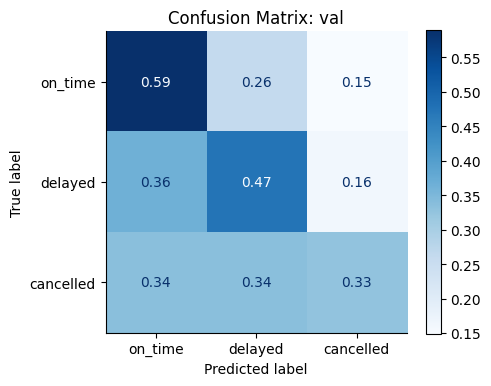

In [6]:
def evaluate(model, X, y_true, label='val'):
    y_pred = model.predict(X)
    mf1 = f1_score(y_true, y_pred, average='macro')
    print(f'\n{label} macro F1: {mf1:.4f}')
    print(classification_report(y_true, y_pred,
          target_names=['on_time','delayed','cancelled'], zero_division=0))
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, ax = plt.subplots(figsize=(5,4))
    disp = ConfusionMatrixDisplay(cm_norm, display_labels=['on_time','delayed','cancelled'])
    disp.plot(ax=ax, colorbar=True, cmap='Blues')
    ax.set_title(f'Confusion Matrix: {label}')
    plt.tight_layout()
    import os
    os.makedirs('/home/t1sanchez/capstone/modelos', exist_ok=True)
    fig.savefig(f'/home/t1sanchez/capstone/modelos/v3_confusion_{label}.png', dpi=150, bbox_inches='tight')
    plt.show()
    return mf1

mf1_val = evaluate(model, X_val, y_val, 'val')

## Val Results

## Weather Feature Importance

Highlighting weather features in red to see how much they contribute vs the baseline flight features.

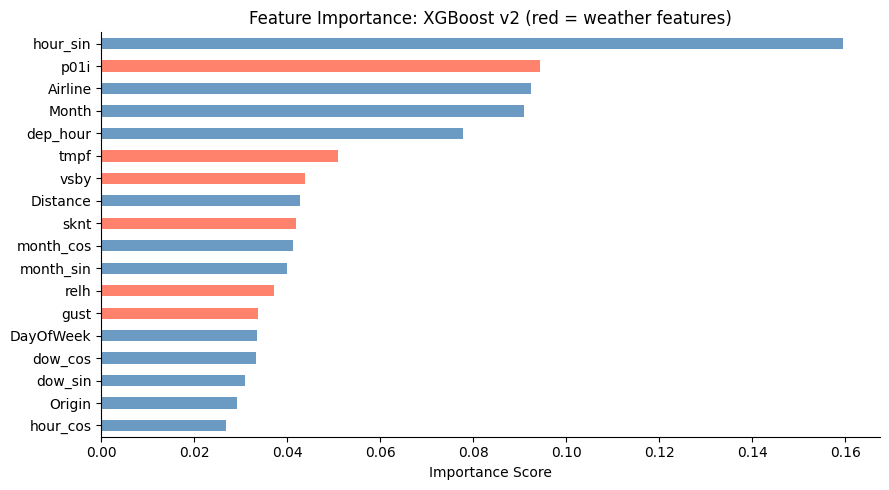

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)
colors = ['tomato' if f in ['tmpf','vsby','sknt','p01i','relh','gust'] else 'steelblue'
          for f in importance.index]
importance.plot(kind='barh', color=colors, alpha=0.8, ax=ax)
ax.set_title('Feature Importance: XGBoost v2 (red = weather features)')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Test Set Results


test macro F1: 0.3714
              precision    recall  f1-score   support

     on_time       0.84      0.51      0.63   3091391
     delayed       0.32      0.48      0.38    863057
   cancelled       0.06      0.42      0.10    123191

    accuracy                           0.50   4077639
   macro avg       0.41      0.47      0.37   4077639
weighted avg       0.71      0.50      0.56   4077639



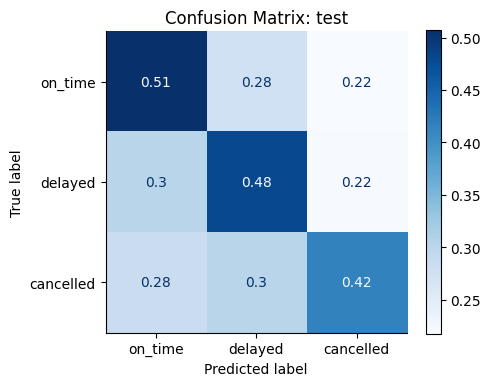

In [8]:
mf1_test = evaluate(model, X_test, y_test, 'test')

## v1 vs v2 vs v3 Comparison

Did class weights actually help cancelled recall?

               model cancelled recall  val macro F1  test macro F1
   v1 (flights only)               0%        0.3054         0.2954
      v2 (+ weather)               1%        0.3641         0.3594
v3 (+ class weights)              42%        0.3750         0.3770


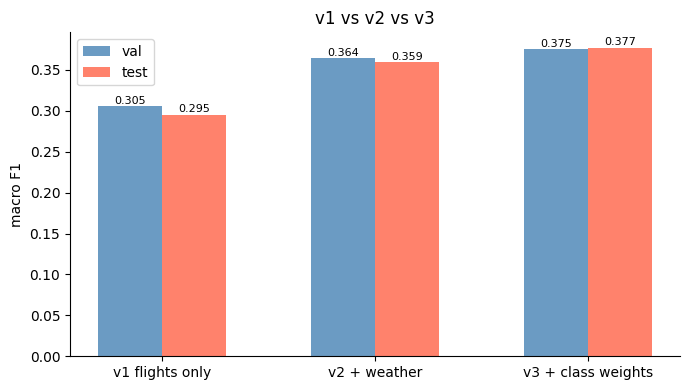

In [12]:
# results from previous versions
v1_val,  v1_test  = 0.3054, 0.2954
v2_val,  v2_test  = 0.3641, 0.3594

# v3 results
v3_val,  v3_test  = 0.3750, 0.3770

comparison = pd.DataFrame({
    'model':         ['v1 (flights only)', 'v2 (+ weather)', 'v3 (+ class weights)'],
    'cancelled recall': ['0%', '1%', '42%'],
    'val macro F1':  [v1_val,  v2_val,  v3_val],
    'test macro F1': [v1_test, v2_test, v3_test],
})
print(comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(3)
width = 0.3
ax.bar(x - width/2, [v1_val,  v2_val,  v3_val],  width, label='val',  color='steelblue', alpha=0.8)
ax.bar(x + width/2, [v1_test, v2_test, v3_test], width, label='test', color='tomato',    alpha=0.8)
for i, (v, t) in enumerate(zip([v1_val, v2_val, v3_val], [v1_test, v2_test, v3_test])):
    ax.text(i - width/2, v + 0.003, f'{v:.3f}', ha='center', fontsize=8)
    ax.text(i + width/2, t + 0.003, f'{t:.3f}', ha='center', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(['v1 flights only', 'v2 + weather', 'v3 + class weights'])
ax.set_ylabel('macro F1')
ax.set_title('v1 vs v2 vs v3')
ax.legend()
plt.tight_layout()
fig.savefig('/home/t1sanchez/capstone/modelos/v3_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary


Recall looks pretty balanced across all three classes: on_time (0.51), 
delayed (0.48), cancelled (0.42). At first glance that seems like a win.


But look at cancelled precision: 0.06. That means the model is predicting 
cancellations constantly and getting it wrong 94% of the time. It's finding 
real cancellations but also flagging way too many flights that aren't actually 
cancelled. Not very useful in practice.


For v4 we're going to try a **cascade**: one model dedicated to just spotting 
cancellations, and another for delays. The idea is that specializing each 
model on one problem should help with the precision issue.
